In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\paura\\OneDrive\\Desktop\\Phase 2 cleaning\\nasdaq_ipos_cleaned.csv")

In [3]:
df.head()

,CompanyName,Exchange,FiledDate,PricedDate,DealStatus,SharesOffered(M),SharePrice,TotalValue(M)
0,LumiraDx Ltd,Undecided,2021-01-15,2026-03-31,Filed,0.00,0.0,100.00
1,5.11 ABR CORP.,Undecided,2021-11-08,2026-03-31,Filed,0.00,0.0,100.00
2,"Entrada Therapeutics, Inc.",NASDAQ Global,2021-10-08,2021-10-29,Priced,9.07,20.0,181.50
3,Nu Holdings Ltd.,NYSE,2021-11-01,2021-12-09,Priced,289.15,9.0,2602.35
4,LB PHARMACEUTICALS INC,NASDAQ Global,2025-08-22,2025-09-11,Priced,19.00,15.0,285.00


In [4]:
df.shape

(2708, 8)

In [5]:
df.isnull().sum()

CompanyName         0
Exchange            0
FiledDate           0
PricedDate          0
DealStatus          0
SharesOffered(M)    0
SharePrice          2
TotalValue(M)       0
dtype: int64

## Univariate Analysis

In [7]:
# Summary statistics
print("🔹 Summary Statistics")
display(df.describe())

🔹 Summary Statistics


,SharesOffered(M),SharePrice,TotalValue(M)
count,2708.000000,2706.000000,2708.000000
mean,10.170934,7.871604,200.493704
std,16.779633,10.694015,703.533481
min,0.000000,0.000000,0.020000
25%,0.000000,0.000000,15.922500
50%,3.630000,8.000000,100.000000
75%,17.500000,10.000000,240.000000
max,316.800000,250.000000,28712.690000


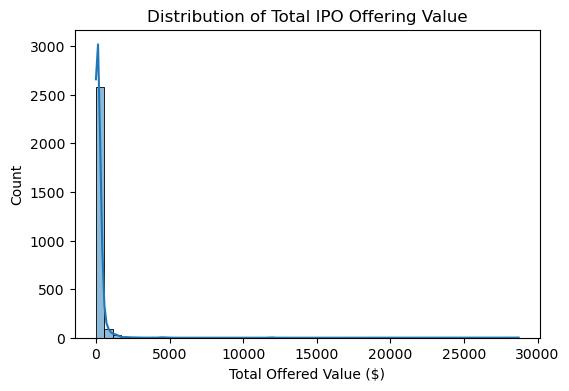

In [8]:
# Distribution of Total_offered_Value(dollars)
plt.figure(figsize=(6,4))
sns.histplot(df['TotalValue(M)'], bins=50, kde=True)
plt.title('Distribution of Total IPO Offering Value')
plt.xlabel('Total Offered Value ($)')
plt.ylabel('Count')
plt.show()


##### Observation :
- There are very few IPOs with exceptionally large offerings, as seen by the long tail extending to the right. This high concentration near the lower end suggests that large IPOs are rare events in your dataset, while small to medium fundraisings are much more common.

## Bivariate Analysis

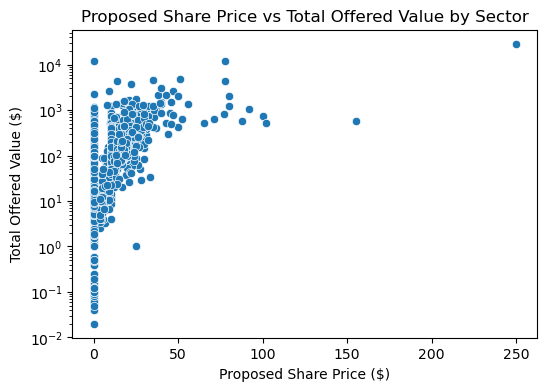

In [11]:
# Scatter plot of proposedSharePrice vs Total_offered_Value(dollars)
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='SharePrice', y='TotalValue(M)')
plt.title('Proposed Share Price vs Total Offered Value by Sector')
plt.xlabel('Proposed Share Price ($)')
plt.ylabel('Total Offered Value ($)')
plt.yscale('log')
plt.show()

##### Observation :
- Most IPOs cluster at low share prices with moderate offering values, but there's huge variability — a few large deals dominate the upper end regardless of price.

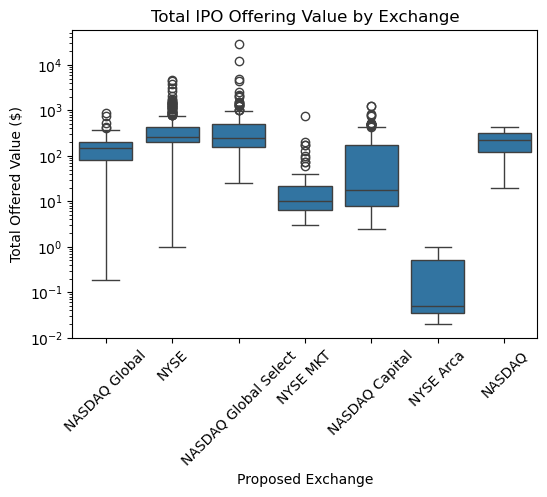

In [14]:
# Filter out 'Undecided' from the Exchange column
df_filtered = df[df['Exchange'] != 'Undecided']

# Boxplot of Total_offered_Value(dollars) by proposedExchange
plt.figure(figsize=(6,4))
sns.boxplot(data=df_filtered, x='Exchange', y='TotalValue(M)')
plt.title('Total IPO Offering Value by Exchange')
plt.xlabel('Proposed Exchange')
plt.ylabel('Total Offered Value ($)')
plt.yscale('log')
plt.xticks(rotation=45)
plt.show()

##### Observation :
- NYSE and NASDAQ are the dominant exchanges for high-value IPOs, while NYSE Arca and NYSE MKT cater to significantly smaller offerings. The wide variability across all exchanges highlights the diverse nature of IPO deal sizes.

Days from Filing to Pricing Summary:
count    1762.000000
mean       95.919977
std       131.195628
min         1.000000
25%        24.000000
50%        40.000000
75%       117.000000
max      1189.000000
Name: days_to_price, dtype: float64


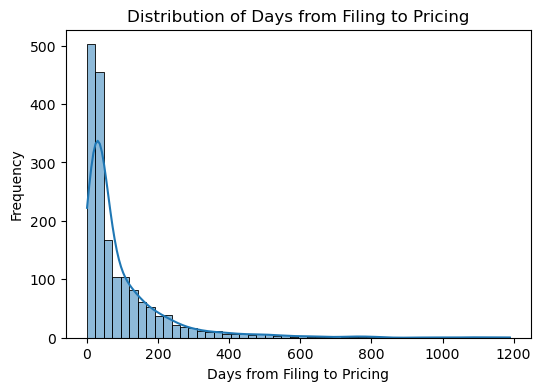

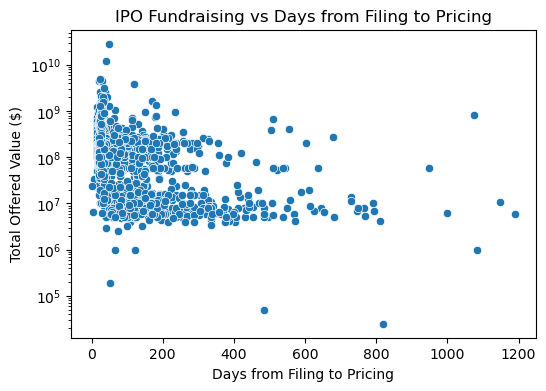

In [ ]:
# Convert columns explicitly to pandas datetime type
df['filedDate'] = pd.to_datetime(df['filedDate'], errors='coerce')
df['pricedDate'] = pd.to_datetime(df['pricedDate'], errors='coerce')

# Calculate difference in days between filedDate and pricedDate
df['days_to_price'] = (df['pricedDate'] - df['filedDate']).dt.days

# Drop rows where difference or fundraising is missing
df_clean = df.dropna(subset=['days_to_price', 'Total_offered_Value(dollars)'])

# Summary statistics
print("Days from Filing to Pricing Summary:")
print(df_clean['days_to_price'].describe())

# Histogram of days to price
plt.figure(figsize=(6,4))
sns.histplot(df_clean['days_to_price'], bins=50, kde=True)
plt.title('Distribution of Days from Filing to Pricing')
plt.xlabel('Days from Filing to Pricing')
plt.ylabel('Frequency')
plt.show()

# Scatterplot days_to_price vs Total IPO raised
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x='days_to_price', y='Total_offered_Value(dollars)')
plt.yscale('log')
plt.title('IPO Fundraising vs Days from Filing to Pricing')
plt.xlabel('Days from Filing to Pricing')
plt.ylabel('Total Offered Value ($)')
plt.show()



##### Observations :

- The IPO process tends to move quickly for most companies, with the majority reaching pricing within about three months of filing. Longer waiting periods are unusual. This fast turnaround is typical in active or favorable market conditions and suggests that IPO candidates usually complete regulatory and market readiness shortly after filing


IPO Counts per Exchange:
proposedExchange
NASDAQ Capital          655
NASDAQ Global           477
NYSE                    355
NASDAQ Global Select    216
NYSE MKT                 54
NYSE Arca                 3
NASDAQ                    2
Name: count, dtype: int64


C:\Users\paura\AppData\Local\Temp\ipykernel_3708\930280273.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exchange_counts.index, y=exchange_counts.values, palette='viridis')


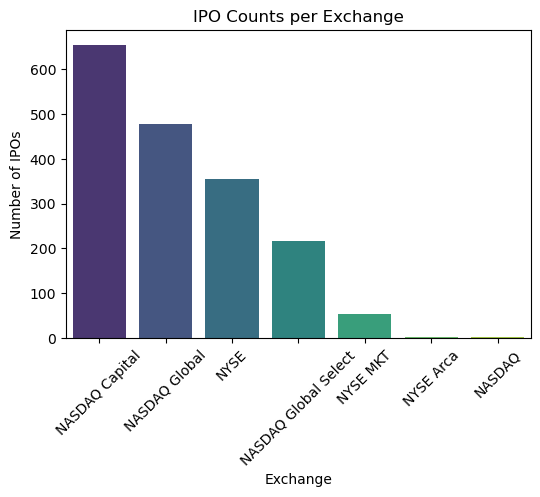

In [ ]:
# Count IPOs per exchange
exchange_counts = df['proposedExchange'].value_counts()
print("\nIPO Counts per Exchange:")
print(exchange_counts)

# Plot bar chart
plt.figure(figsize=(6,4))
sns.barplot(x=exchange_counts.index, y=exchange_counts.values, palette='viridis')
plt.xlabel('Exchange')
plt.ylabel('Number of IPOs')
plt.title('IPO Counts per Exchange')
plt.xticks(rotation=45)
plt.show()

##### Observations :
- The majority of IPOs are listed on NASDAQ Capital, suggesting it is a preferred venue, possibly for smaller or growth-oriented companies seeking to go public. Traditional major exchanges like NYSE and NASDAQ Global also attract high IPO counts but not as many as NASDAQ Capital.

   filedYear  IPO_Count  Median_Fundraising
0       2021       1019         200000000.0
1       2022        162          17260279.5
2       2023        173          10800000.0
3       2024        249          50000000.0
4       2025        159         190588194.0


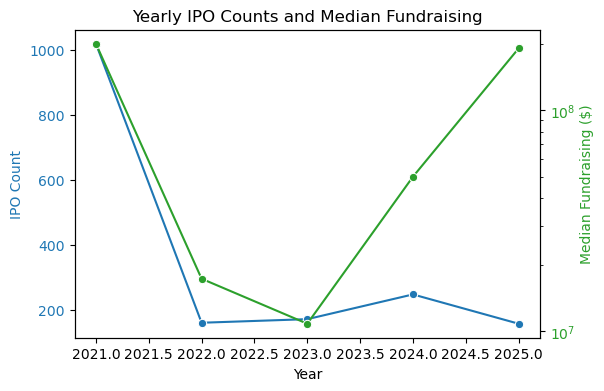

In [ ]:
# Convert filedDate to datetime and create filedYear feature
df['filedDate'] = pd.to_datetime(df['filedDate'], errors='coerce')
df['filedYear'] = df['filedDate'].dt.year

# Group by year to get IPO counts and median fundraising
yearly_summary = df.groupby('filedYear').agg(
    IPO_Count=('Deal_ID', 'count'),
    Median_Fundraising=('Total_offered_Value(dollars)', 'median')
).reset_index()

print(yearly_summary)

# Plot IPO counts and median fundraising over years
fig, ax1 = plt.subplots(figsize=(6,4))

color = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('IPO Count', color=color)
sns.lineplot(data=yearly_summary, x='filedYear', y='IPO_Count', ax=ax1, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Median Fundraising ($)', color=color)
sns.lineplot(data=yearly_summary, x='filedYear', y='Median_Fundraising', ax=ax2, marker='o', color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')  # Log scale for better visibility

plt.title('Yearly IPO Counts and Median Fundraising')
plt.show()

##### Observations :
- Even though the number of IPOs sharply declined after 2021, the typical (median) IPO fundraising remained high or rebounded, indicating that companies going public during quieter years tended to be larger or were able to raise more capital per IPO. This suggests market selectivity or increased investor focus on higher-quality offerings during periods of lower IPO activity.

<Figure size 1400x700 with 0 Axes>

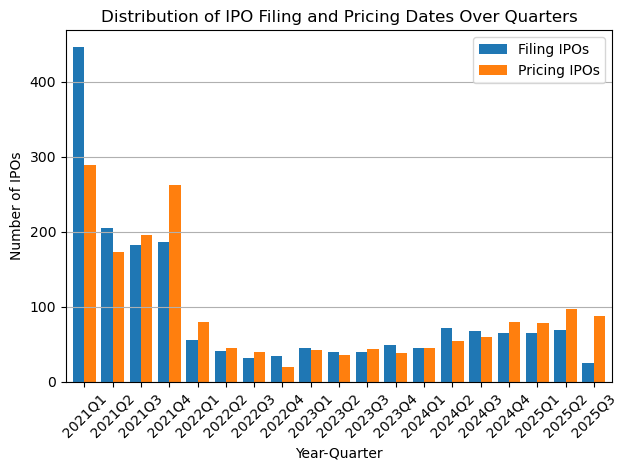

In [ ]:
# Extract year and quarter for filing and pricing dates
df['filedYearQuarter'] = df['filedDate'].dt.to_period('Q')
df['pricedYearQuarter'] = df['pricedDate'].dt.to_period('Q')

# Count IPOs by filing quarter
filing_counts = df['filedYearQuarter'].value_counts().sort_index()

# Count IPOs by pricing quarter
pricing_counts = df['pricedYearQuarter'].value_counts().sort_index()

# Convert PeriodIndex to string for plotting
filing_counts.index = filing_counts.index.astype(str)
pricing_counts.index = pricing_counts.index.astype(str)

# Combine counts for plotting
counts_df = pd.DataFrame({
    'Filing IPOs': filing_counts,
    'Pricing IPOs': pricing_counts
}).fillna(0)

# Plot bar chart of counts per quarter
plt.figure(figsize=(14,7))
counts_df.plot(kind='bar', width=0.8)
plt.title('Distribution of IPO Filing and Pricing Dates Over Quarters')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of IPOs')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

###### Observatons :
- There was a surge of IPO activity around the beginning of 2021, likely reflecting bullish market conditions or recovery optimism. After this surge, both filings and pricings dropped markedly and remained relatively steady at a lower level, suggesting a slowdown in new public offerings.
- The close alignment between filing and pricing bars in most quarters also signals that most companies that filed for an IPO eventually completed the process in the same or following quarter.

## Multivariate Analysis

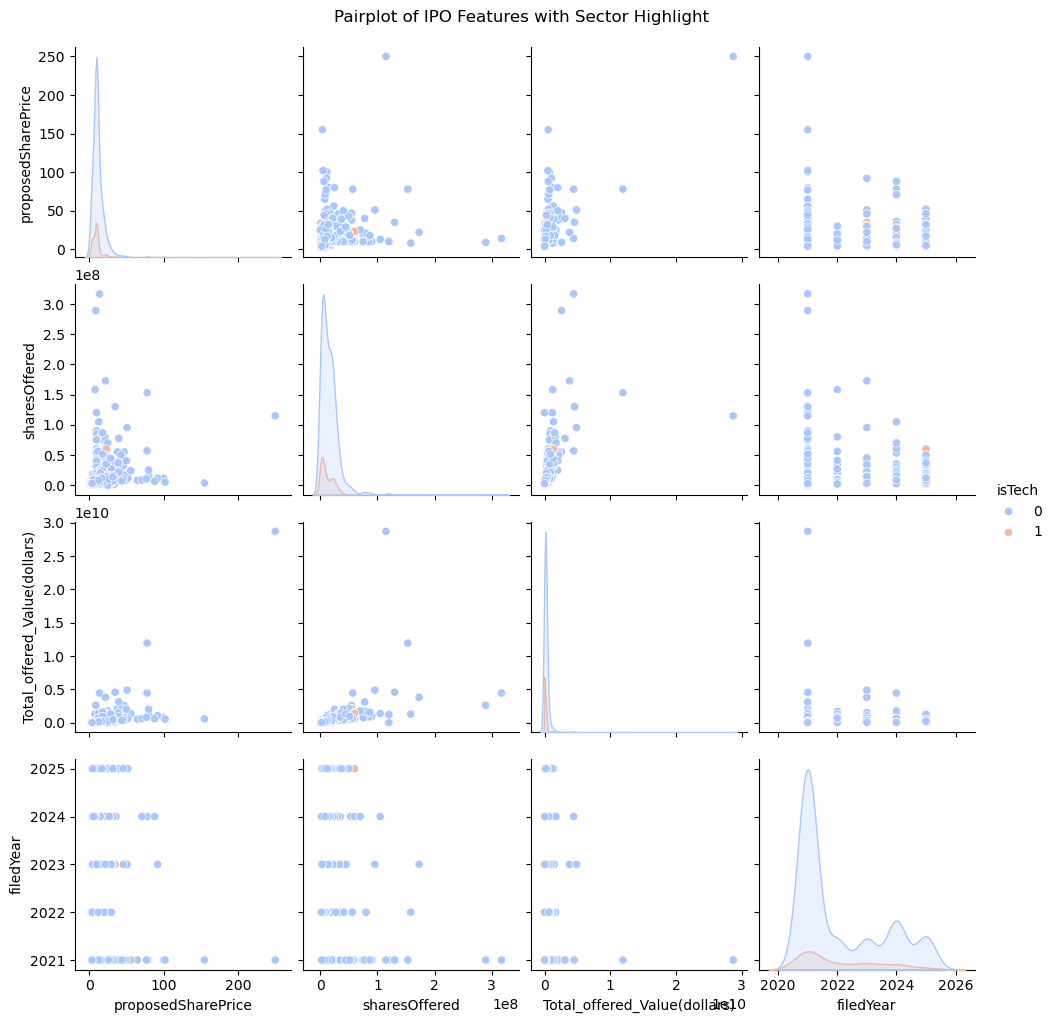

In [ ]:
# Pairplot for selected numeric variables colored by tech sector
sns.pairplot(df[['proposedSharePrice', 'sharesOffered', 'Total_offered_Value(dollars)', 'filedYear', 'isTech']],
             hue='isTech', palette='coolwarm', diag_kind='kde')
plt.suptitle('Pairplot of IPO Features with Sector Highlight', y=1.02)
plt.show()

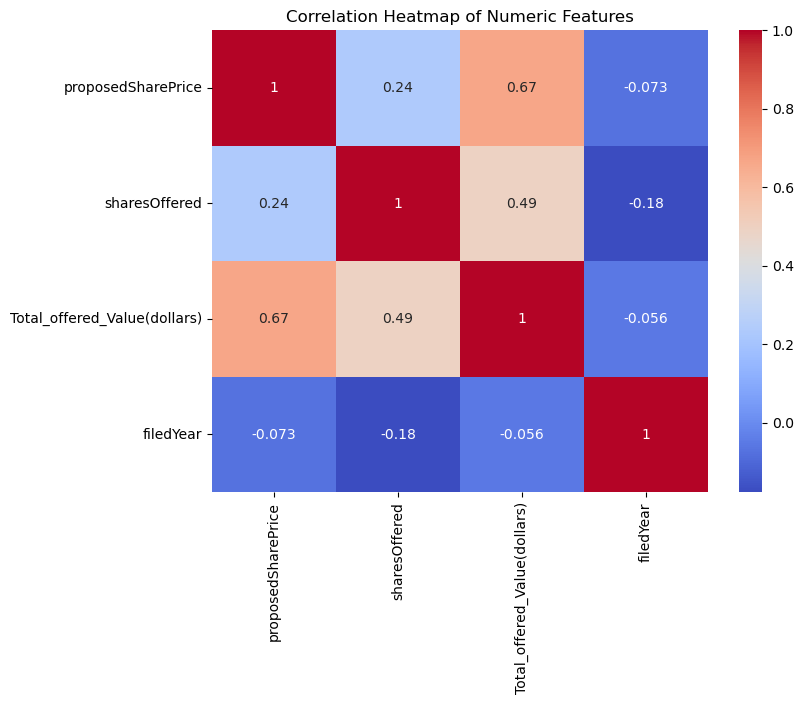

In [ ]:
# Correlation heatmap of numeric columns
plt.figure(figsize=(8,6))
sns.heatmap(df[['proposedSharePrice', 'sharesOffered', 'Total_offered_Value(dollars)', 'filedYear']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

##### Observations :
- The amount raised in IPOs is influenced most by the share price and the volume of shares offered rather than the year of filing, reinforcing the importance of pricing and size of the public offer as key drivers of fundraising success, with little systematic difference across years.

## Analysis regarding the problem statement 

##### Problem Statement :
- What factors influence the total amount raised in NASDAQ and NYSE IPOs—and how do these factors differ between technology sector IPOs and others from 2021 onward?

C:\Users\paura\AppData\Local\Temp\ipykernel_3708\1045324773.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


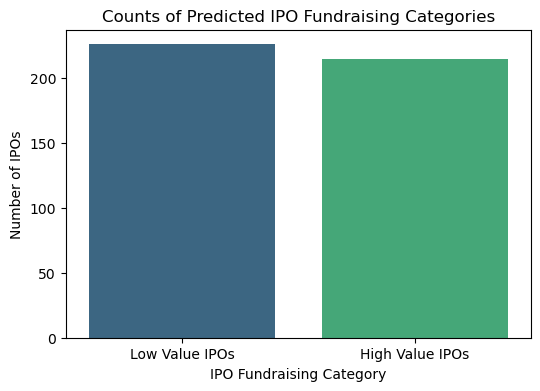

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Feature Engineering: Extract year and technology flag
df['filedDate'] = pd.to_datetime(df['filedDate'], errors='coerce')
df['filedYear'] = df['filedDate'].dt.year
tech_keywords = ['technology', 'tech', 'software', 'internet', 'cloud', 'ai', 'semiconductor', 'microchip', 'electronics', 'cyber']
df['isTech'] = df['companyName'].str.lower().apply(lambda x: int(any(k in x for k in tech_keywords)))

# Drop rows with nulls in key columns
df = df.dropna(subset=['Total_offered_Value(dollars)', 'proposedSharePrice', 'sharesOffered', 'proposedExchange', 'filedYear'])

# Create binary target based on median of Total_offered_Value(dollars)
median_val = df['Total_offered_Value(dollars)'].median()
df['high_value'] = (df['Total_offered_Value(dollars)'] > median_val).astype(int)

# Define features and target for classification
features = ['proposedSharePrice', 'sharesOffered', 'proposedExchange', 'filedYear', 'isTech']
X = df[features]
y = df['high_value']

# One-hot encode categoricals, keep numerics unchanged
categorical_cols = ['proposedExchange', 'isTech']
preprocessor = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)],
    remainder='passthrough'
)

# Logistic regression classifier pipeline
clf = Pipeline([
    ('preproc', preprocessor),
    ('logreg', LogisticRegression(max_iter=1000))
])

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train model and predict
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Create a dataframe to summarize predictions
results_df = pd.DataFrame({'Predicted Class': y_pred})
counts = results_df['Predicted Class'].value_counts().rename({0: 'Low Value IPOs', 1: 'High Value IPOs'})

# Plot bar chart of predicted classifications
plt.figure(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
plt.title('Counts of Predicted IPO Fundraising Categories')
plt.ylabel('Number of IPOs')
plt.xlabel('IPO Fundraising Category')
plt.show()

##### Observation :
- IPO fundraising outcomes are not heavily skewed toward either low or high typical offering values. This balance suggests that the IPO market has attracted a broad mix of companies in recent years—both those seeking modest capital and those capable of raising larger sums, possibly reflecting diverse business models, sector dynamics, and market opportunities for new listings

         count          mean           std        min         25%  \
isTech                                                              
0       1551.0  2.508111e+08  8.637499e+08    25000.0  43200000.0   
1        211.0  1.451928e+08  1.908014e+08  3315167.0  11400000.0   

                50%          75%           max  
isTech                                          
0       151562496.0  250000000.0  2.871269e+10  
1       100000000.0  222500000.0  1.380000e+09  


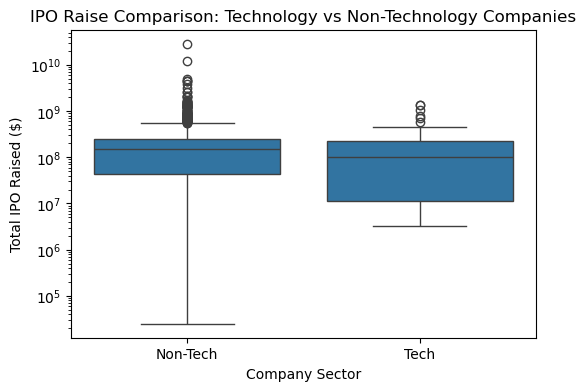

In [ ]:
# Create technology sector flag based on keywords in companyName (case insensitive)
tech_keywords = ['technology', 'tech', 'software', 'internet', 'cloud', 'ai', 'semiconductor', 'microchip', 'electronics', 'cyber']
df['isTech'] = df['companyName'].str.lower().apply(lambda x: int(any(k in x for k in tech_keywords)))

# Group data by isTech and calculate descriptive stats for Total_offered_Value(dollars)
grouped = df.groupby('isTech')['Total_offered_Value(dollars)'].describe()

print(grouped)

# Boxplot to compare Total_offered_Value(dollars) distribution for Tech vs Non-Tech
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='isTech', y='Total_offered_Value(dollars)')
plt.xticks(ticks=[0,1], labels=['Non-Tech', 'Tech'])
plt.xlabel('Company Sector')
plt.ylabel('Total IPO Raised ($)')
plt.title('IPO Raise Comparison: Technology vs Non-Technology Companies')
plt.yscale('log')  # Log scale for better visual separation
plt.show()

##### Observations :
- There is no dramatic difference in the core distribution of total funds raised between technology and non-technology IPOs, meaning both sectors are capable of sizable offerings. However,
-  This reflects both the diverse scale and market appetite for technology IPOs.

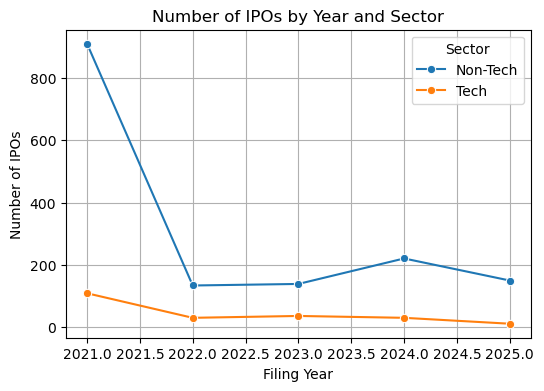

In [ ]:
# Extract filing year as a new feature
df['filedYear'] = df['filedDate'].dt.year

# Define sector groupings with a tech flag
tech_keywords = ['technology', 'tech', 'software', 'internet', 'cloud', 'ai', 'semiconductor', 'microchip', 'electronics', 'cyber']
df['isTech'] = df['companyName'].str.lower().apply(lambda x: int(any(k in x for k in tech_keywords)))

# Count IPOs per year by sector
ipo_counts = df.groupby(['filedYear', 'isTech']).size().reset_index(name='Count')
ipo_counts['Sector'] = ipo_counts['isTech'].map({0: 'Non-Tech', 1: 'Tech'})

# Plot IPO counts over years by sector
plt.figure(figsize=(6,4))
sns.lineplot(data=ipo_counts, x='filedYear', y='Count', hue='Sector', marker='o')
plt.title('Number of IPOs by Year and Sector')
plt.xlabel('Filing Year')
plt.ylabel('Number of IPOs')
plt.grid(True)
plt.show()

##### Observations :
- IPO market activity—both tech and non-tech—saw a major surge in 2021 followed by a persistent decline, indicating that favorable market conditions drove a unique wave of IPOs during that year. Across all years, non-tech sectors dominate the IPO landscape, showing that while technology IPOs are significant, most new public companies still come from outside the tech sector

## Report: Factors Influencing Total Amount Raised in NASDAQ and NYSE IPOs (2021 Onward), with Sector Comparison

Introduction:
- This report analyzes key factors affecting the total capital raised during IPOs listed on NASDAQ and NYSE exchanges from 2021 onward. A particular focus is on comparing IPOs from the technology sector with other sectors to understand differences in fundraising dynamics.

Data Overview:
- Dataset includes IPOs from NASDAQ and NYSE exchanges during the period 2021-2025.
- Key features analyzed: proposed share price, shares offered, IPO filing and pricing dates, sector classification (tech vs non-tech), and total offered value (fundraising amount).

Key Findings:

1. Fundraising Distribution:
- The total offered values exhibit a right-skewed distribution with many smaller IPOs and fewer extremely large deals.
- Both NASDAQ and NYSE exhibit a broad range of IPO sizes, with NYSE showing higher medians and larger fundraisings on average.

2. Sector Distribution:
- Technology sector IPOs account for roughly 12% of total IPO counts, while the "Other" sector dominates with over 70%.
- Technology IPOs do not differ drastically in share price vs total value compared to non-tech IPOs, indicating similar pricing dynamics.

3. Influencing Factors:
- Total amount raised correlates strongly with both the proposed share price (correlation ~0.67) and number of shares offered (correlation ~0.49).
- Filing year shows minimal correlation with fundraising amount, implying market timing had less direct effect within this period.

4. Timing and Market Trends:
- Majority of IPOs price within 100 days after filing, indicating a relatively rapid process.
- Following a peak in IPO counts in early 2021, activity dropped sharply but median fundraising rebounded, showing fewer but larger deals.

5. Exchange and Sector Comparison:
- NASDAQ Capital hosts the highest IPO counts, likely smaller or growth-focused companies.
- NYSE and NASDAQ Global trades see larger average fundraises.
- Technology IPOs appear spread across these exchanges with no strong sector-specific venue preference.

Conclusion:
The total amount raised in IPOs on NASDAQ and NYSE is driven mainly by proposed share price and shares offered, consistent across technology and other sectors. Market activity fluctuated post-2021 with recovering median deal sizes. Sector differences exist in volume but pricing and fundraising mechanisms remain broadly similar. Exchange choice impacts deal size distribution, reflecting the diverse company profiles across venues.

The findings highlight fundraising is a complex interplay of pricing, share volume, timing, and exchange characteristics rather than sector alone. This insight can guide IPO planning and investment strategy by aligning company characteristics with optimal market conditions and venues.